## First experimentations with landscapes, _flow() and _integrate()

First objective : using _flow() and integrate() to display cell trajectories

Note : for the moment, I will only consider landscape without time dependencies

In [524]:
%load_ext autoreload
%autoreload 2   

# adding jax functions
import jax.numpy as jnp
import jax.random as jrnd
from jax import grad, jit
from jax import tree_util

from evoscape.jax_functions import _flow, _integrate

## same imports as examples_basic.py
import numpy as np
import matplotlib.pyplot as plt

from evoscape.landscapes import Landscape
from evoscape.modules import Node, UnstableNode, Center, NegCenter
from evoscape.landscape_visuals import *
from evoscape.morphogen_regimes import mr_const, mr_sigmoid, mr_piecewise

plt.style.use('default')
plt.rcParams.update({'figure.dpi': 100})
plt.rcParams.update({'font.size': 15})  

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Creating a simple landscape : 

Node: x=-1.5; y=0.0; a=1.5; s=1.
Node: x=1.5; y=0.0; a=2.; s=0.8
Landscape with modules:
Node: x=-1.5; y=0.0; a=1.5; s=1.,
Node: x=1.5; y=0.0; a=2.; s=0.8


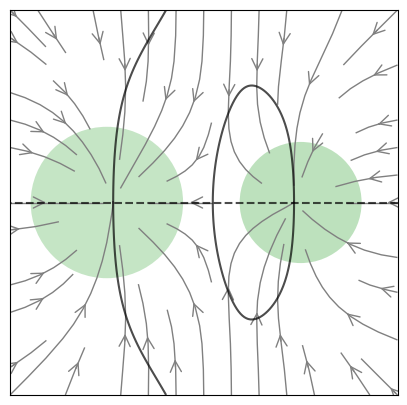

In [525]:
# Landscape with one regime + simple visualization
%autoreload
M1 = Node(x=-1.5, y=0., a=1.5, s=1.)
M2 = Node(x=1.5, y=0., a=2., s=0.8)
## M3 = UnstableNode(x=0., y=1., a=1.3, s=0.8)

module_list = [M1, M2] # , M3]

for M in module_list:
    print(M)

landscape = Landscape(module_list, A0 = 0.05, regime=mr_const, n_regimes=1)
print(landscape)

L = 3.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

fig = visualize_landscape(landscape, xx, yy, regime=0, color_scheme='fp_types')


Converting the landscape into a pytree (simply to dictionnaries module_params and module_infos).

module_params will have their gradient computed, whereas module_infos will not.

module_params contains xs, ys, a_list, sig_list.

In [526]:
t = 0. # pas de dépendance en temps pour l'instant
q = jnp.array(np.random.randn(2,10,1)) ## y0 en fait

module_params, module_infos = landscape.to_pytree(t)

q_flat = q.reshape(2, -1)

Computing the flow of the initial cells

In [527]:
flow = _flow(t, q_flat, module_params, module_infos, return_potentials=False)
print(flow)

[[-0.45958352  0.6116547  -0.7428296  -0.73066413  0.2530058  -0.51177955
   0.537001   -0.03174155  0.15505128 -0.73039067]
 [ 0.5045029   0.05815042 -0.21886334  0.27798578 -0.8634899   0.64540076
   0.48543125  0.68439573  0.7798123  -0.04380602]]


To compute the gradient, I create a dummy get_state() funciton so we can move on.

In [528]:

def get_states(t,y):
    return jnp.zeros(y.shape[1])


Computing cell trajectories with _integrate()

In [529]:
## creating hyper_params_dict

key = jrnd.PRNGKey(42)
nt = 100
ndt = 10 
noise = 0.1
t0 = 0.
tf = 5.

key_final, traj, states = _integrate(key,  q_flat, t0, tf, nt, ndt, noise, module_infos, module_params, get_states)


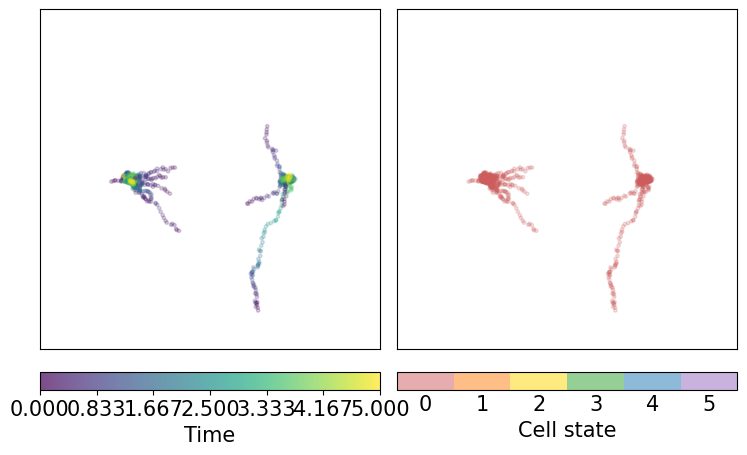

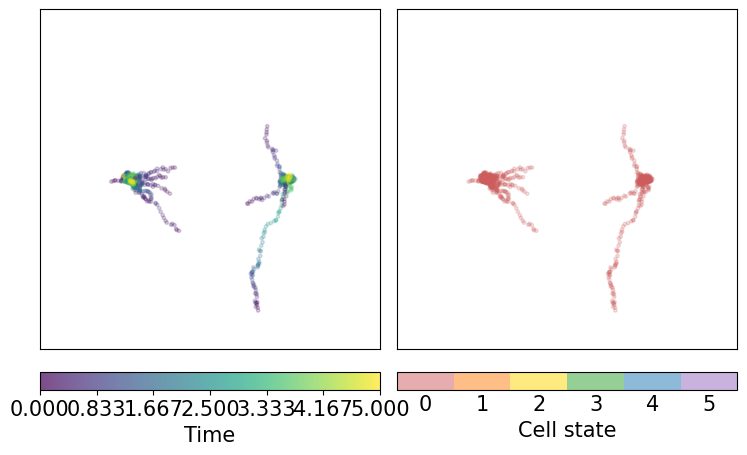

In [530]:
#  Add cells with a scattered initial condition and plot trajectories
n = 100
L = 3

plot_traj(traj, states, t0, tf, nt, L)

In order to take the gradient, we need a simple fitness function. It returns the squares of the distance of the particles from the center.

We should see the two clusters going next to each other during the gradient descent (if it works well).

In [531]:
def fitness(module_params, module_infos, key,  q_flat, t0, tf, nt, ndt, noise, get_states):
    key_final, traj, states = _integrate(key,  q_flat, t0, tf, nt, ndt, noise, module_infos, module_params, get_states)
    final_coordinates = traj[:, :, -1]
    return jnp.sum(final_coordinates ** 2)

result = fitness(module_params, module_infos, key,  q_flat, t0, tf, nt, ndt, noise, get_states)

print(result)

result_grad = grad(fitness)(module_params, module_infos, key,  q_flat, t0, tf, nt, ndt, noise, get_states)


19.715855


### Implementing a really simple gradient descent.

In [532]:
lr = 0.01


grad_fn = grad(fitness)

for i in range(50):
    grad_ = grad_fn(module_params, module_infos, key,  q_flat, t0, tf, nt, ndt, noise, get_states)
    module_params = tree_util.tree_map(
        lambda p, g : p - lr * g,
        module_params,
        grad_
    )


print(module_params)

{'a_list': (Array(1.6265132, dtype=float32, weak_type=True), Array(1.8849449, dtype=float32, weak_type=True)), 'sig_list': (Array(1.381991, dtype=float32, weak_type=True), Array(1.1263843, dtype=float32, weak_type=True)), 'xs': Array([[-0.8804358],
       [ 0.7835411]], dtype=float32), 'ys': Array([[-0.00516161],
       [ 0.00074567]], dtype=float32)}


Displaying the landscape : the two clusters are closer to the center.

Landscape with modules:
Node: x=-0.8804358; y=-0.0051616123; a=1.6265132; s=1.381991,
Node: x=0.7835411; y=0.00074566796; a=1.8849449; s=1.1263843


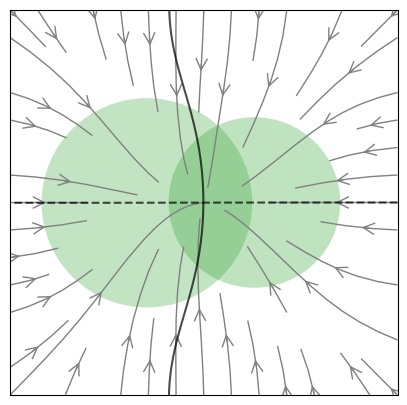

In [533]:
landscape = Landscape.from_pytree(module_params, module_infos)
print(landscape)

L = 3.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

fig = visualize_landscape(landscape, xx, yy, regime=0, color_scheme='fp_types')
